<a href="https://colab.research.google.com/github/hig3r/mva/blob/2026/E03/mva_2026_E03_02_multivariate_normal_scatterplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# mva_2026_E03_02_multivariate_normal 多変量正規分布の生成 with scipy.stats
- 学籍番号 [ ]
- 氏名 [ ]

In [ ]:
import numpy as np # 数値計算ライブラリ
import pandas as pd # データ解析ライブラリ
import matplotlib.pyplot as plt # グラフ描画ライブラリ
%matplotlib inline

from scipy import stats # 科学計算確率統計ライブラリ

# from sklearn.linear_model import LinearRegression # scikit-learn の線形重回帰ライブラリ

#!pip install japanize_matplotlib
#import japanize_matplotlib # 日本語フォント

## 例1：独立：それぞれ正規分布にしたがう独立な確率変数$(Y_1,Y_2)$

### サンプルの生成

確率統計Iで学んだように，次のようにして，正規分布にしたがう確率変数を定義できるのでした．

- scipy.stats https://docs.scipy.org/doc/scipy/reference/stats.html

ここで，キーワード引数 loc には毋平均値$\mu$，scaleには母標準偏差$\sigma$（母分散$\sigma^2$ ではなく）を設定します．

In [ ]:
rvy1=stats.norm(loc=3,scale=5)
rvy2=stats.norm(loc=4,scale=2)

サイズ$n$の標本抽出は，メソッド`.rvs(size=n)` で行います．返り値は，NumPyの1次元配列です．

In [ ]:
n=10
y1=rvy1.rvs(size=n)
y2=rvy2.rvs(size=n)
y1

array([ 2.60846292,  3.20569832, -2.82309134, -7.36898793,  2.86555067,
        1.52232063,  4.8534468 , -1.28163803, -1.45885332,  1.88986062])

このままで扱える部分もありますが，2次元配列にまとめると，

In [ ]:
Y_a = np.column_stack([y1, y2])
print("shape:", Y_a.shape)
print(Y_a)

shape: (10, 2)
[[ 2.60846292  3.54685401]
 [ 3.20569832  2.59863045]
 [-2.82309134  3.29509848]
 [-7.36898793  3.02903654]
 [ 2.86555067  4.16506225]
 [ 1.52232063  4.23421369]
 [ 4.8534468   4.69689182]
 [-1.28163803  4.97042747]
 [-1.45885332  5.49472303]
 [ 1.88986062  4.78691947]]


### 可視化

In [ ]:
Y_a[:,0] # 1次元配列 y1に戻る

array([ 2.60846292,  3.20569832, -2.82309134, -7.36898793,  2.86555067,
        1.52232063,  4.8534468 , -1.28163803, -1.45885332,  1.88986062])

0列目，1列目から1次元配列を取り出し，scatterメソッドの位置引数に与えます

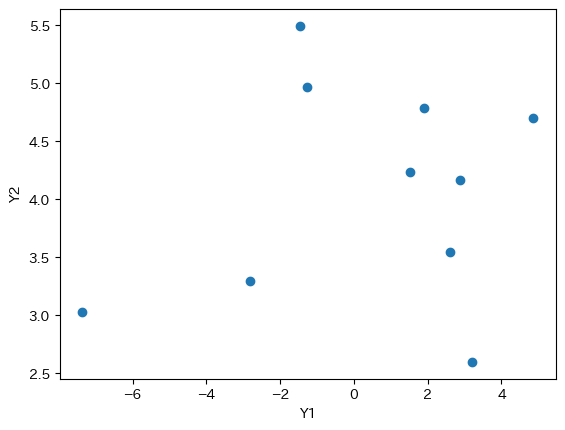

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Y_a[:,0], Y_a[:,1])
ax.set_xlabel("Y1")
ax.set_ylabel("Y2")
plt.show()

## 例2：非独立：2次元正規分布にしたがう確率変数$(Y_1,Y_2)$

### サンプルの生成

キーワード引数mean で毋平均値ベクトル $\mathbf{\mu}$ をNumPy1次元配列で, covで母共分散行列$\Sigma$を対称なNumPy2次元配列で与えます．ここでは$p=2$ですが，一般の型でできます．

In [ ]:
mu = np.array([3, 4])
cov = np.array([[25, 5],[5, 4]])
rvy = stats.multivariate_normal(mean=mu, cov=cov)

サイズ$n$の標本抽出は，メソッド`.rvs(size=n)` で行います．返り値は，NumPyの2次元配列，サイズは$n \times p$ です．

In [ ]:
n=10
Y_b = rvy.rvs(size=n)
print("shape:", Y_b.shape)
print(Y_b)

shape: (10, 2)
[[ 3.61319418  6.48250201]
 [ 5.43361357  4.55371517]
 [10.53086386  5.03693151]
 [ 6.33707441  3.37896213]
 [ 7.01112203  2.84117724]
 [ 6.76693314  3.69415193]
 [ 8.46130237  5.07376433]
 [-4.93768197  1.8934655 ]
 [ 4.95102951  6.28298394]
 [ 4.85136672  6.19784202]]


#### 補足

例1で扱った独立な$\mathbf{Y}=(Y_1,Y_2)$は，共分散行列を対角にすることによって，`multivariate_normal`で一度に生成できます．

In [ ]:
rvy_c=stats.multivariate_normal(mean=[3,4],cov=[[4**2,0],[0,2**2]])
Y_c=rvy_c.rvs(size=n)

### 可視化

0列目，1列目から1次元配列を取り出し，scatterメソッドの位置引数に与えます

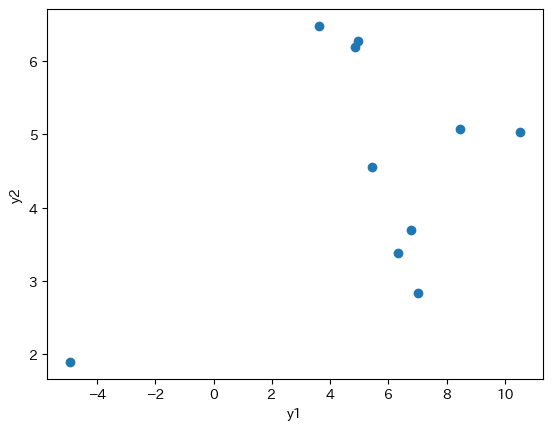

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Y_b[:,0], Y_b[:,1])
ax.set_xlabel("y1")
ax.set_ylabel("y2")
plt.show()

2つのデータを重ねる可視化．`.scatter()`メソッドを実行するたびに色が変わる

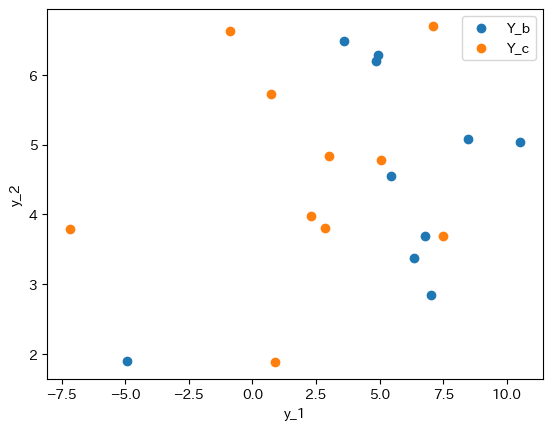

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Y_b[:,0], Y_b[:,1])
ax.scatter(Y_c[:,0], Y_c[:,1])
ax.set_xlabel("y_1")
ax.set_ylabel("y_2")
ax.legend(["y_1","y_2"]) # 凡例をつける
plt.show()